In [95]:
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [96]:
infile = r"C:\Users\seifert\Pictures\Temp\Out\ResultTotal_5\res.csv"
df = pd.read_csv(infile, sep=';')

In [97]:
d = dict(df)

In [98]:
d.keys()

dict_keys(['Unnamed: 0', 'total_id', 'img_id', 'crop_id', 'img_fn', 'crop_fn', 'p1', 'p2', 'cat', 'conf', 'w_px', 'h_px', 'mid_x_nm', 'mid_y_nm', 'centroid_x_nm', 'centroid_y_nm', 'NN1_nm', 'NN2_nm', 'NN3_nm', 'NN4_nm', 'NN5_nm', 'area', 'area_nm', 'span_x_nm', 'span_y_nm', 'long_axis_nm', 'short_axis_nm', 'angle'])

In [99]:
ids = np.unique(d['img_id'])

In [100]:
def get_dict_from_id(img_id):
    retd = {}
    idcs = []
    for num, i in tqdm(enumerate(d['img_id'])):
        if i == img_id:
            idcs.append(num)

    for key in d.keys():
        retd[key] = []
        for num, val in enumerate(d[key]):
            if num in idcs:
                retd[key].append(val)


    return retd

In [101]:
dict_0 = get_dict_from_id(63)

2256it [00:00, 2244390.38it/s]


In [102]:
dict_0

{'Unnamed: 0': [1587,
  1588,
  1589,
  1590,
  1591,
  1592,
  1593,
  1594,
  1595,
  1596,
  1597,
  1598,
  1599],
 'total_id': [1587,
  1588,
  1589,
  1590,
  1591,
  1592,
  1593,
  1594,
  1595,
  1596,
  1597,
  1598,
  1599],
 'img_id': [63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63, 63],
 'crop_id': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 'img_fn': ['C:\\Users\\seifert\\Pictures\\Temp\\DataLib\\Data library\\Dimer in long axis\\50x20\\50x20 (18).tif',
  'C:\\Users\\seifert\\Pictures\\Temp\\DataLib\\Data library\\Dimer in long axis\\50x20\\50x20 (18).tif',
  'C:\\Users\\seifert\\Pictures\\Temp\\DataLib\\Data library\\Dimer in long axis\\50x20\\50x20 (18).tif',
  'C:\\Users\\seifert\\Pictures\\Temp\\DataLib\\Data library\\Dimer in long axis\\50x20\\50x20 (18).tif',
  'C:\\Users\\seifert\\Pictures\\Temp\\DataLib\\Data library\\Dimer in long axis\\50x20\\50x20 (18).tif',
  'C:\\Users\\seifert\\Pictures\\Temp\\DataLib\\Data library\\Dimer in long axis\\50x20\\50x20 (18).tif

In [103]:
midpoints_x = [x for x in dict_0['mid_x_nm']]
midpoints_y = [x for x in dict_0['mid_y_nm']]
centroid_x = [x for x in dict_0['centroid_x_nm']]
centroid_y = [x for x in dict_0['centroid_y_nm']]
conf = [x for x in dict_0['conf']]


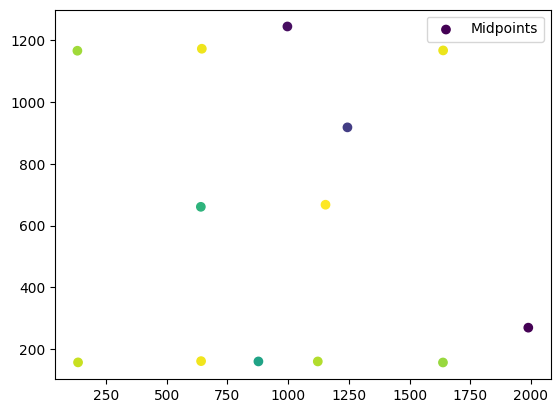

In [104]:
plt.scatter(midpoints_x, midpoints_y, c=conf, label='Midpoints')
plt.legend()

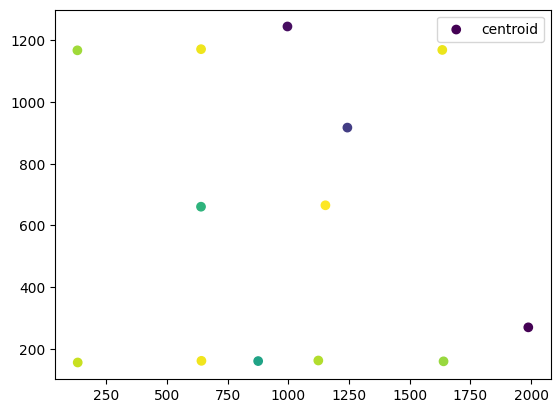

In [105]:
plt.scatter(centroid_x, centroid_y, c=conf, label='centroid')
plt.legend()

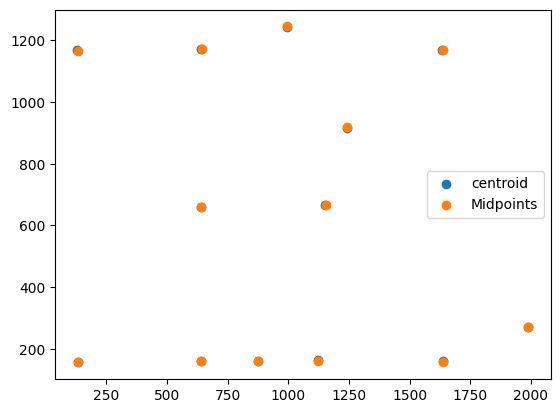

In [106]:
plt.scatter(centroid_x, centroid_y, label='centroid')
plt.scatter(midpoints_x, midpoints_y, label='Midpoints')
plt.legend()

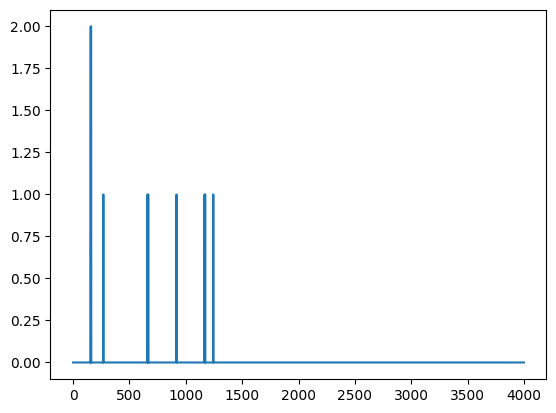

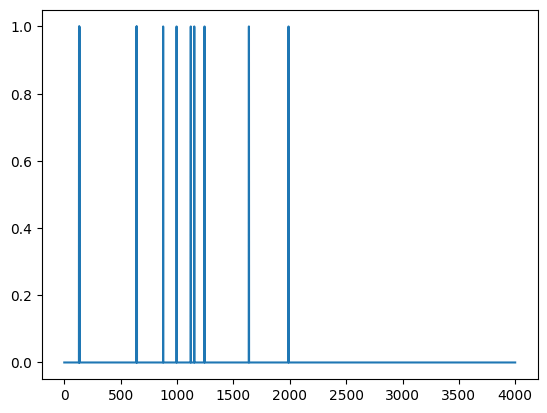

In [107]:
arr = np.zeros((4000, 4000))
x = midpoints_x
y = midpoints_y
for pt in zip(x, y):
    xpos = int(pt[0])
    ypos = int(pt[1])
    arr[xpos, ypos] += 1

# plt.imshow(arr)

x_axis = np.sum(arr, axis=0)
plt.plot(x_axis)
plt.show()

y_axis = np.sum(arr, axis=1)
plt.plot(y_axis)
plt.show()

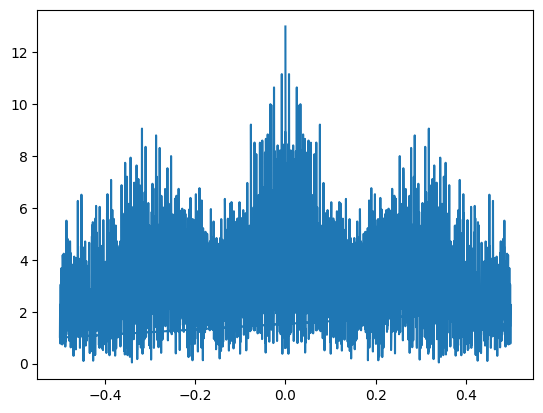

In [108]:
fft_y = np.fft.fft(y_axis)
fft_freq = np.fft.fftfreq(len(x_axis))
plt.plot(fft_freq, np.abs(fft_y))

In [109]:
x

[1989.1740405953992,
 996.9554533152908,
 1244.2493748308525,
 877.5371691474966,
 640.3924871447903,
 1637.685694181326,
 131.93502138024357,
 1122.1249039242218,
 134.64131204330175,
 1638.3632801082542,
 644.4528064952639,
 641.4078267929635,
 1153.9246765899863]

In [110]:
x_values = x

(array([23.,  2.,  0.,  0.,  2.,  0.,  6.,  0.,  2.,  0.,  0.,  0.,  6.,
         4.,  2.,  0.,  0.,  0.,  6.,  6.,  0.,  4.,  0.,  0.,  0.,  6.,
         4., 22.,  0.,  0.,  0.,  0.,  6.,  0.,  4.,  0.,  0.,  0.,  0.,
         0., 10.,  0.,  0.,  0.,  2.,  0.,  6.,  0.,  0.,  0.,  0.,  0.,
         0., 18.,  2.,  2.,  0.,  0.,  0.,  6.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  6.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  4.,  4.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  4.]),
 array([   0.        ,   18.57239019,   37.14478038,   55.71717058,
          74.28956077,   92.86195096,  111.43434115,  130.00673135,
         148.57912154,  167.15151173,  185.72390192,  204.29629211,
         222.86868231,  241.4410725 ,  260.01346269,  278.58585288,
         297.15824307,  315.73063327,  334.30302346,  352.87541365,
         371.44780384,  390.02019404,  408.59258423,  427.16497442,
         445.73736461,  46

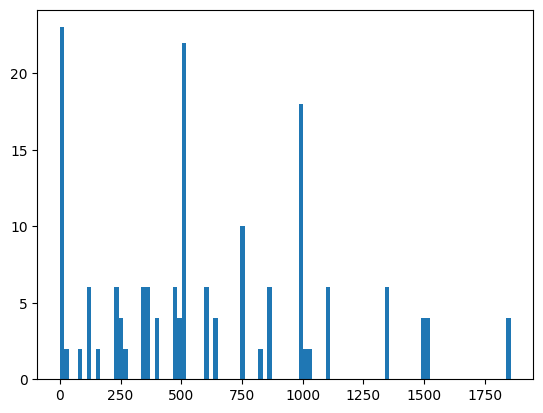

In [111]:
ds = []
for xv1 in x_values:
    for xv2 in x_values:
        d = abs(xv1 - xv2)
        ds.append(d)

plt.hist(ds, bins=100)


In [112]:
from IPython import display
import pylab as pl

def itplot(x, y):
    pl.plot(x, y, c='gray')
    display.clear_output(wait=True)
    display.display(pl.gcf())

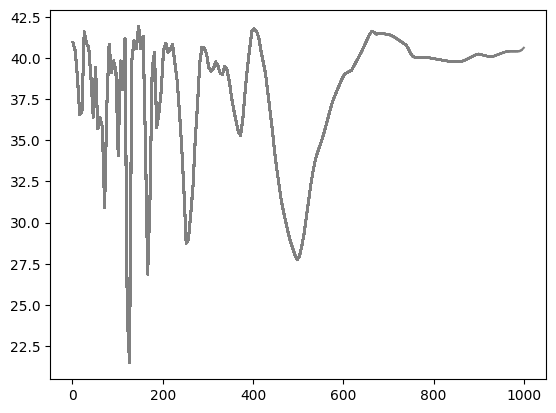

100%|██████████| 200/200 [00:14<00:00, 13.83it/s]


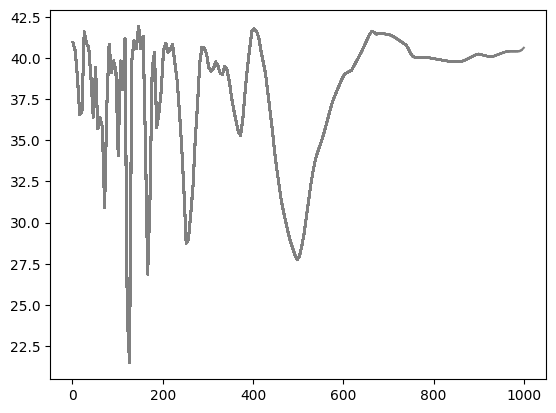

In [113]:
test_periods = np.linspace(1, 1000, 200)
test_freqs = [1/x for x in test_periods]
confs = []
tps = []

for tp in tqdm(test_freqs):
    locconf = 0
    for d in ds:
        mult = d * tp
        frac = abs(round(mult) - mult)
        locconf += frac

    confs.append(locconf)
    tps.append(1/tp)
    itplot(tps, confs)



In [114]:
closest = tps[np.argmin(confs)]
closest

126.50251256281406

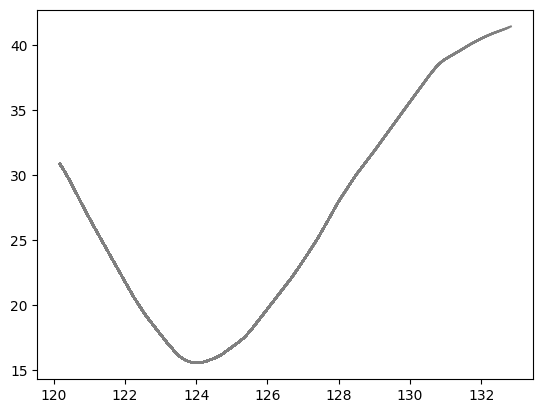

100%|██████████| 200/200 [00:11<00:00, 17.64it/s]


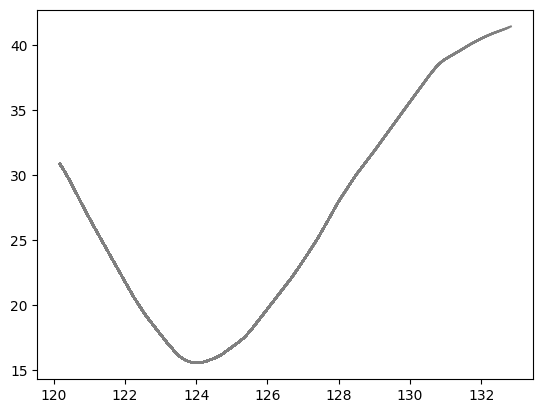

In [115]:
print(closest)
test_periods = np.linspace(closest * 0.95, 1.05 * closest, 200)
test_freqs = [1/x for x in test_periods]
sml_confs = []
sml_tps = []

for tp in tqdm(test_freqs):
    locconf = 0
    for d in ds:
        mult = d * tp
        frac = abs(round(mult) - mult)
        locconf += frac

    sml_confs.append(locconf)
    sml_tps.append(1/tp)
    itplot(sml_tps, sml_confs)

In [116]:
freq_x = sml_tps[np.argmin(sml_confs)]
freq_x

124.05510214388525

(array([41.,  0.,  0.,  0.,  0.,  0.,  2.,  4.,  0.,  2.,  8.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  4.,  6.,  0.,  0.,
         0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  2.,  2.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  6., 24.,  2.,  0.,  0.,  0.,  0.,
         0.,  4.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0., 10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  4.,  2.,  0.,  0.,  0.,  0.,  0.,  2.,  0.,
         0., 22.,  8.,  0.,  0.,  0.,  0.,  0., 10.]),
 array([   0.        ,   10.87280013,   21.74560026,   32.61840039,
          43.49120052,   54.36400065,   65.23680078,   76.10960091,
          86.98240104,   97.85520117,  108.7280013 ,  119.60080143,
         130.47360156,  141.34640169,  152.21920182,  163.09200195,
         173.96480208,  184.83760221,  195.71040234,  206.58320247,
         217.4560026 ,  228.32880273,  239.20160286,  250.07440299,
         260.94720312,  27

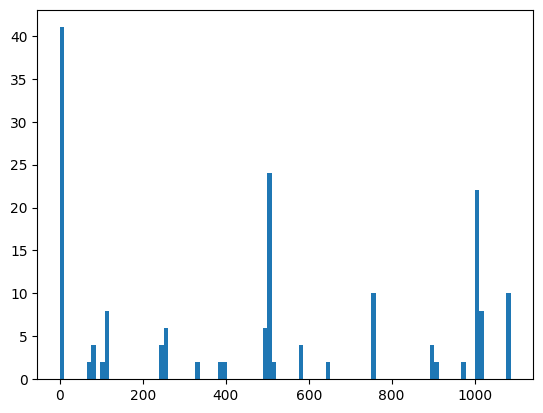

In [117]:
y_values = midpoints_y
dsy = []
for xv1 in y_values:
    for xv2 in y_values:
        d = abs(xv1 - xv2)
        dsy.append(d)

plt.hist(dsy, bins=100)

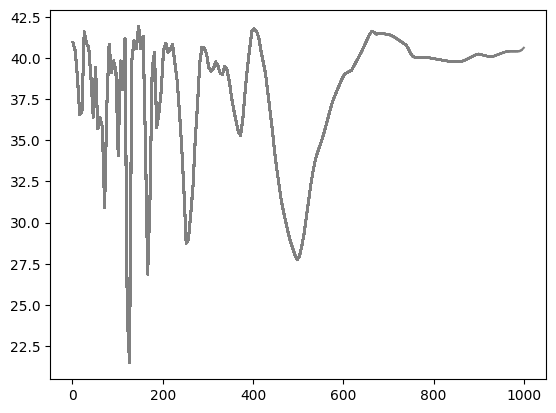

100%|██████████| 200/200 [00:14<00:00, 13.67it/s]


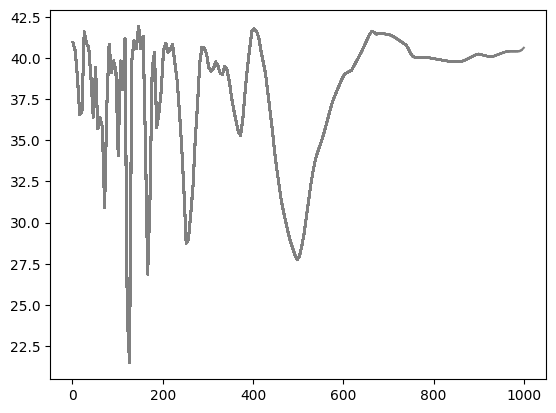

In [118]:
test_periods = np.linspace(1, 1000, 200)
test_freqs = [1/x for x in test_periods]
confs = []
tps = []

for tp in tqdm(test_freqs):
    locconf = 0
    for d in ds:
        mult = d * tp
        frac = abs(round(mult) - mult)
        locconf += frac

    confs.append(locconf)
    tps.append(1/tp)
    itplot(tps, confs)

In [119]:
closest = tps[np.argmin(confs)]
closest

126.50251256281406

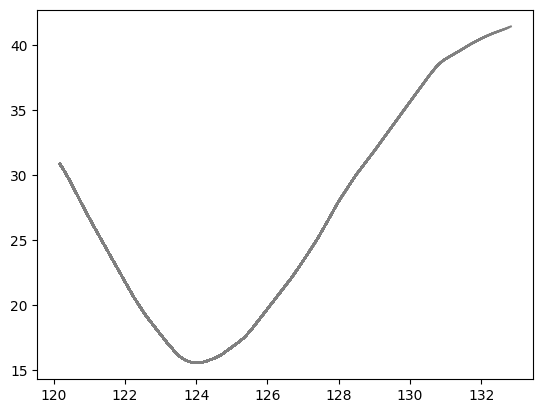

100%|██████████| 200/200 [00:11<00:00, 17.28it/s]


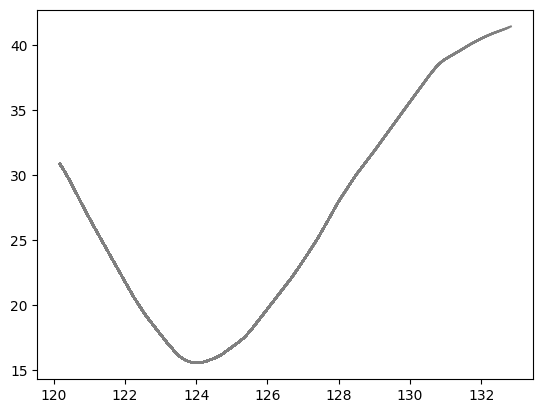

In [120]:
test_periods = np.linspace(closest * 0.95, 1.05 * closest, 200)
test_freqs = [1/x for x in test_periods]
sml_confs = []
sml_tps = []

for tp in tqdm(test_freqs):
    locconf = 0
    for d in ds:
        mult = d * tp
        frac = abs(round(mult) - mult)
        locconf += frac

    sml_confs.append(locconf)
    sml_tps.append(1/tp)
    itplot(sml_tps, sml_confs)

In [121]:
freq_y = sml_tps[np.argmin(sml_confs)]
freq_y

124.05510214388525